In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import simple_norm

from spectral_cube import SpectralCube as sc
from regions import RectangleSkyRegion
from tqdm.notebook import tqdm

from pybaselines import Baseline

from joblib import Parallel, delayed
from functools import partial

from pybaselines import Baseline
from pybaselines.utils import gaussian, relative_difference
from pybaselines._banded_utils import PenalizedSystem
from pybaselines._weighting import _arpls

from rotation_model_numpy import calc_v_dev
from astropy.coordinates import SkyCoord

# disable the Parameter Warning
import warnings
from pybaselines.utils import ParameterWarning
warnings.filterwarnings("ignore", category=ParameterWarning)

%matplotlib widget

%matplotlib widget

import sys
print(sys.version)
print(sys.executable)

3.13.11 | packaged by conda-forge | (main, Dec  6 2025, 11:24:03) [GCC 14.3.0]
/home/firestar/.miniforge/bin/python


In [2]:
# Combine CRAFTS data cubes
# Test (positive): xlo=113*u.deg, xhi=125*u.deg, ylo=-13*u.deg, yhi=-7*u.deg, zlo=100 * u.km/u.s, zhi=300 * u.km/u.s
# Test (negative): xlo=60*u.deg, xhi=80*u.deg, ylo=-6*u.deg, yhi=-2*u.deg, zlo=-255 * u.km/u.s, zhi=-55 * u.km/u.s

file1 = "../CRAFTS/South/00_DEC_-13.0_-3.0__11_RA_110.0_120.0__-600kms_600kms.I.fits"  # -10 ~ -30
file2 = "../CRAFTS/South/00_DEC_-13.0_-3.0__12_RA_120.0_130.0__-600kms_600kms.I.fits"  # 10 ~ -10

cube1 = sc.read(file1)
data1 = cube1.unmasked_data[:, :, :]
data1 = np.nan_to_num(data1)
del cube1

cube2 = sc.read(file2)
data2 = cube2.unmasked_data[:, :, :]
data2 = np.nan_to_num(data2)
combined_header = cube2.wcs.to_header()
del cube2

In [14]:
# Combine the images
combined_data = np.concatenate((data2, data1), axis=2)

# Update the header for the new combined image
combined_wcs = WCS(combined_header)

combined_cube = sc(data=combined_data, wcs=combined_wcs)

crafts_cube = combined_cube.subcube(xlo=113*u.deg, xhi=125*u.deg, ylo=-13*u.deg, yhi=-7.5*u.deg)
crafts_data = crafts_cube.unmasked_data[:, :, :].value

print(crafts_cube)

SpectralCube with shape=(5962, 221, 481) and unit=K:
 n_x:    481  type_x: RA---CAR  unit_x: deg    range:   112.987500 deg:  124.987500 deg
 n_y:    221  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:   -7.487500 deg
 n_s:   5962  type_s: VRAD      unit_s: m / s  range:  -599897.172 m / s:  599954.336 m / s


In [15]:
def masked_arpls(y, mask=None, lam=1e8, diff_order=2, tol=1e-3, max_iter=50, weights=None):
    """A mask-aware version of the arpls algorithm."""
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ParameterWarning)
        len_y = len(y)
        if mask is None:
            mask = np.ones(len_y, dtype=bool)
            y_fit = y
        else:
            y_fit = 1 * y  # don't want to override the input y, so make a copy
            y_fit[~mask] = 0  # cover that case of nan values in y since 0 * nan = nan rather than 0

        if weights is None:
            weights = np.ones(len_y)
        else:
            weights = 1 * weights  # don't want to override the input weights, so make a copy

        weights[~mask] = 0

        whittaker_system = PenalizedSystem(len(y), lam=lam, diff_order=diff_order)

        for _ in range(max_iter):
            baseline = whittaker_system.solve(
                whittaker_system.add_diagonal(weights), weights * y_fit,
            )

            # ignore masked regions in weighting
            calc_weights, exit_early = _arpls(y[mask], baseline[mask])

            if exit_early:
                break

            new_weights = np.zeros(len_y)
            new_weights[mask] = calc_weights

            if relative_difference(weights, new_weights) < tol:
                break

            weights = new_weights

        return baseline

In [16]:
def pix_to_galactic_l_b(celestial_wcs, xpix, ypix):
    lonlat = celestial_wcs.all_pix2world(xpix, ypix, 0)
    ctypes = celestial_wcs.wcs.ctype
    c0 = ctypes[0].upper()
    if "RA" in c0 or "DEC" in c0:
        sc = SkyCoord(ra=lonlat[0] * u.deg, dec=lonlat[1] * u.deg, frame="fk5")
        gal = sc.galactic
        return gal.l.deg, gal.b.deg
    else:
        return lonlat[0], lonlat[1]

In [17]:
wcs = crafts_cube.wcs
n_v, n_y, n_x = crafts_cube.shape
vel_axis = crafts_cube.spectral_axis.value
nv = len(vel_axis)

i_grid, j_grid = np.meshgrid(np.arange(n_x), np.arange(n_y), indexing='ij')

l_deg, b_deg = pix_to_galactic_l_b(wcs.celestial, i_grid, j_grid)

v_max, v_min = calc_v_dev(l_deg, b_deg, model="poly", v_dev=30)

vmax_map = v_max.T
vmin_map = v_min.T

pos_mask = vel_axis[:, None, None] > vmax_map[None, :, :]
neg_mask = vel_axis[:, None, None] < vmin_map[None, :, :]

# 这是 v_dev > 30 区域
baseline_mask = pos_mask | neg_mask

In [18]:
# 拉平成行谱
dataset = crafts_data.transpose(1, 2, 0).reshape(n_y * n_x, n_v)  # shape (480000, 5962)
baseline_mask_set = baseline_mask.reshape(n_y * n_x, n_v)  # shape (480000, 5962)

In [19]:
baselines = np.empty_like(dataset)  # shape (480000, 5962)

# 并行计算
results = Parallel(n_jobs=-1, backend="loky", return_as="generator", verbose=5)(
    delayed(masked_arpls)(dataset[i], baseline_mask_set[i]) for i in range(len(dataset))
)

for i, baseline in enumerate(results):
    baselines[i] = baseline

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 134 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 5184 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 11520 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 19008 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 27648 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 37440 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 48384 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done 60480 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done 73728 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done 88128 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 103680 tasks      | elapsed:   20.0s
[Parallel(n_jobs=-1)]: Done 106301 out of 106301 | elapsed:   20.6s finished


In [20]:
baselines = baselines.T.reshape(n_v, n_y, n_x)
corrected = crafts_data - baselines
corrected = corrected << u.K
corrected_cube = sc(data=corrected, wcs=crafts_cube.wcs)
corrected_slab = corrected_cube.spectral_slab(100 * u.km/u.s, 300 * u.km/u.s)

print(corrected_slab)

SpectralCube with shape=(995, 221, 481) and unit=K:
 n_x:    481  type_x: RA---CAR  unit_x: deg    range:   112.987500 deg:  124.987500 deg
 n_y:    221  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:   -7.487500 deg
 n_s:    995  type_s: VRAD      unit_s: m / s  range:    99965.887 m / s:  300041.780 m / s


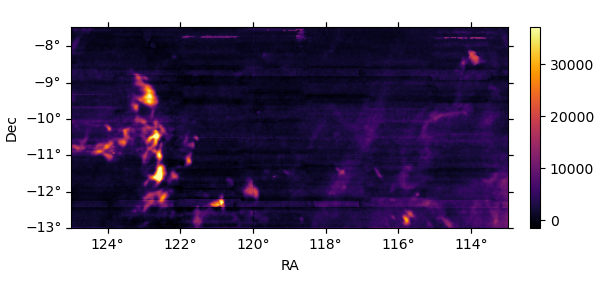

In [21]:
def displayimage(cube, region=None):
    img = cube.moment(order=0).value  # moment 0
    fig, ax = plt.subplots(
        figsize=(6, 3), layout="compressed", subplot_kw={"projection": cube.wcs.celestial}
    )
    vmin, vmax = np.nanpercentile(img, [0.1, 99.9])
    im = ax.imshow(img, vmin=vmin, vmax=vmax, cmap="inferno", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if region != None:
        region.plot(color="white")
    plt.colorbar(im)
    plt.show()

displayimage(corrected_slab)

In [22]:
corrected_slab.write("test.fits", format="fits", overwrite=True)

In [23]:
hi4pi_cube = sc.read("../HI4PI/HI4PI_ALLSKY_EQ2000_CAR.fits")
hi4pi_test_cube = hi4pi_cube.subcube(xlo=113*u.deg, xhi=125*u.deg, ylo=-13*u.deg, yhi=-7*u.deg, zlo=100 * u.km/u.s, zhi=300 * u.km/u.s)
print(hi4pi_test_cube)
del hi4pi_test_cube.header["SLICE"]
hi4pi_test_cube.write("hi4pi_test.fits", format="fits", overwrite=True)

SpectralCube with shape=(156, 73, 145) and unit=K:
 n_x:    145  type_x: RA---CAR  unit_x: deg    range:   113.000000 deg:  125.000000 deg
 n_y:     73  type_y: DEC--CAR  unit_y: deg    range:   -13.000000 deg:   -7.000000 deg
 n_s:    156  type_s: VRAD      unit_s: m / s  range:   100581.725 m / s:  300255.045 m / s


In [24]:
# Reproject HI4PI test cube to CRAFTS test cube
reprojected_file = "./hi4pi_test_reprojected.fits"

target_header = crafts_cube.wcs.celestial.to_header()

target_header['NAXIS'] = hi4pi_test_cube.ndim
target_header['NAXIS1'] = crafts_cube.shape[2]
target_header['NAXIS2'] = crafts_cube.shape[1]
target_header['NAXIS3'] = hi4pi_test_cube.shape[0]
target_header['CTYPE3'] = hi4pi_test_cube.wcs.wcs.ctype[2]
target_header['CDELT3'] = hi4pi_test_cube.wcs.wcs.cdelt[2]
target_header['CRPIX3'] = hi4pi_test_cube.wcs.wcs.crpix[2]
target_header['CRVAL3'] = hi4pi_test_cube.wcs.wcs.crval[2]
target_header['CUNIT3'] = "m/s"

reprojected_cube = hi4pi_test_cube.reproject(target_header, parallel=True)
reprojected_cube.write(reprojected_file, overwrite=True)